In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('/content/dementia.xlsx', sheet_name='Sheet1')


# Pre-Processing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    float64
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(6), int64(4), object(5)
memory usage: 43.8+ KB


In [ ]:
print("Tota Rows and Columns (Rows,Columns) : ",df.shape)
#print first five rows of the dataset
df.head(5)

Tota Rows and Columns (Rows,Columns) :  (373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1986.550000,0.696106,0.883440
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004.479526,0.681062,0.875539
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678.290000,0.736336,1.045710
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1737.620000,0.713402,1.010000
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1697.911134,0.701236,1.033623


In [ ]:
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.121584,0.729556,1.195460
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.135956,0.037141,0.138105
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1105.652499,0.644399,0.875539
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.330000,0.700191,1.098979
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.041312,0.728789,1.193844
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1596.936793,0.755669,1.292980
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.479526,0.836842,1.587298


In [ ]:
df.isna().sum()

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [ ]:
sum(df.duplicated())

0

In [ ]:
df["SES"].fillna(df["SES"].median(), inplace=True)
df["MMSE"].fillna(df["MMSE"].mean(), inplace=True)

<Axes: xlabel='Group', ylabel='count'>

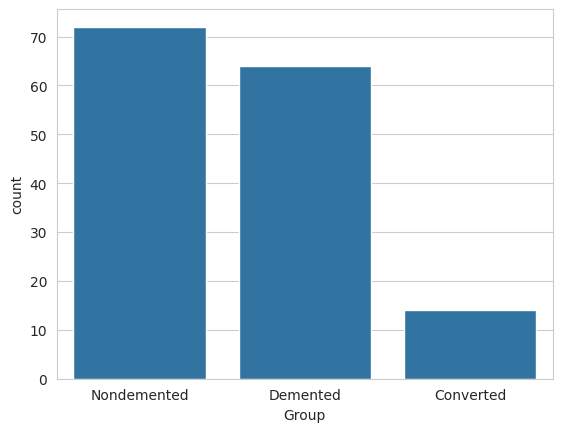

In [ ]:
sns.set_style("whitegrid")
ex_df = df.loc[df['Visit'] == 1]
sns.countplot(x='Group', data=ex_df)

<ipython-input-12-f052a051643f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ex_df['Group'] = ex_df['Group'].replace(['Converted'], ['Demented'])


<Axes: xlabel='Group', ylabel='count'>

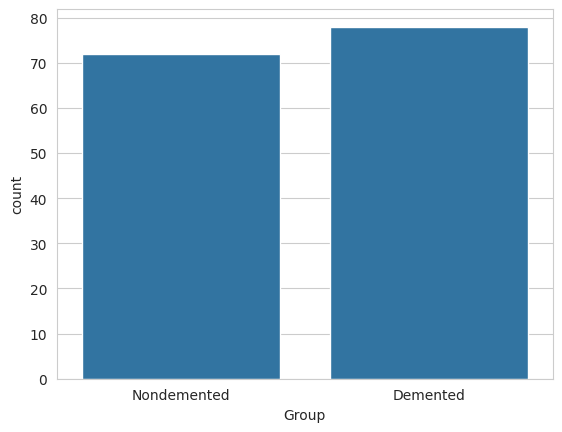

In [ ]:
ex_df['Group'] = ex_df['Group'].replace(['Converted'], ['Demented'])
df['Group'] = df['Group'].replace(['Converted'], ['Demented'])
sns.countplot(x='Group', data=ex_df)

M/F           M   F
Demented     40  38
Nondemented  22  50


Text(0.5, 1.0, 'Gender and Demented rate')

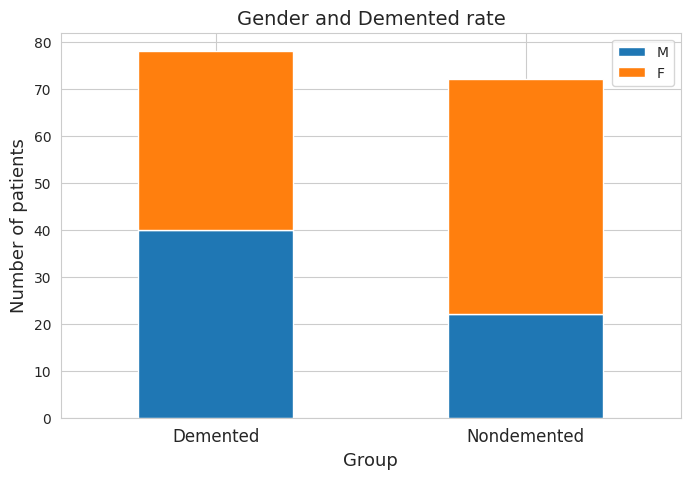

In [ ]:


# bar drawing function
def bar_chart(feature):
    Demented = ex_df[ex_df['Group']=='Demented'][feature].value_counts()
    Nondemented = ex_df[ex_df['Group']=='Nondemented'][feature].value_counts()
    df_bar = pd.DataFrame([Demented,Nondemented])
    df_bar.index = ['Demented','Nondemented']
    df_bar.plot(kind='bar',stacked=True, figsize=(8,5))
    print(df_bar)


# Gender  and  Group ( Female=0, Male=1)
bar_chart('M/F')
plt.xlabel('Group',fontsize=13)
plt.xticks(rotation=0,fontsize=12)
plt.ylabel('Number of patients',fontsize=13)
plt.legend()
plt.title('Gender and Demented rate',fontsize=14)



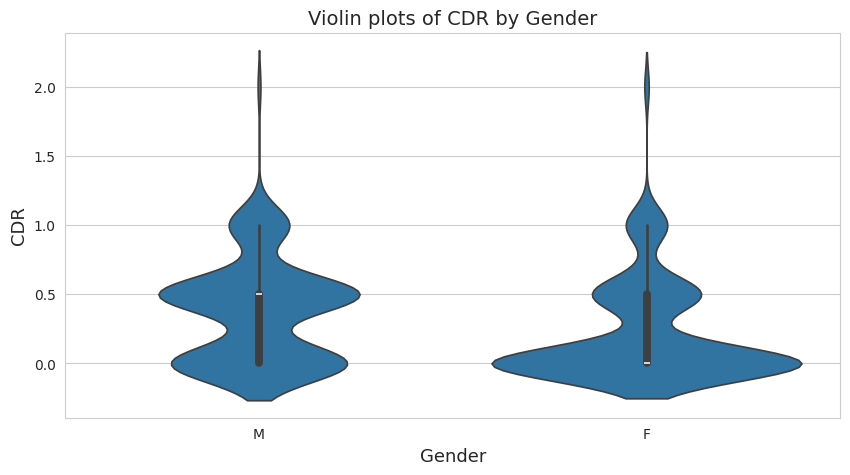

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(x='M/F', y='CDR', data=df)
plt.title('Violin plots of CDR by Gender',fontsize=14)
plt.xlabel('Gender',fontsize=13)
plt.ylabel('CDR',fontsize=13)
plt.show()

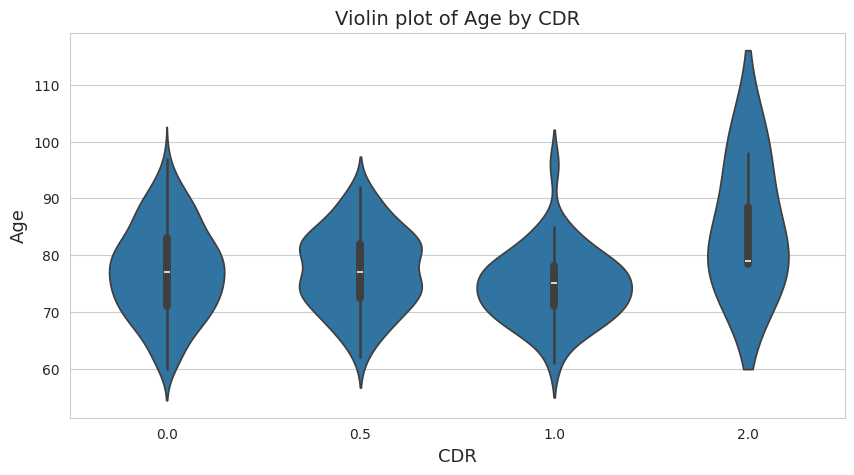

In [ ]:
plt.figure(figsize=(10,5))
sns.violinplot(x='CDR', y='Age', data=df)
plt.title('Violin plot of Age by CDR',fontsize=14)
plt.xlabel('CDR',fontsize=13)
plt.ylabel('Age',fontsize=13)
plt.show()

In [ ]:
#find the outliers in each of the column
def outliers_iqr(ys):
    quartile_1, quartile_3 = np.percentile(ys, [25, 75])
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    return np.where((ys > upper_bound) | (ys < lower_bound))

list_atributes = ['MR Delay','EDUC', "SES", "MMSE","CDR" ,'eTIV', "nWBV", "ASF"]
print("Outliers: \n")
for item in list_atributes:
    print(item,': ',outliers_iqr(df[item]))

Outliers: 

MR Delay :  (array([ 32,  71,  75, 153, 159, 160, 265, 369]),)
EDUC :  (array([107, 108, 109]),)
SES :  (array([136, 137, 138, 161, 162, 179, 180]),)
MMSE :  (array([  4,  25,  26,  43,  44,  51,  52,  60,  88,  89,  90,  93,  94,
        97,  98,  99, 100, 101, 105, 106, 138, 162, 172, 173, 184, 185,
       186, 222, 225, 226, 231, 232, 234, 251, 299, 300, 316, 317, 328,
       332, 360, 366]),)
CDR :  (array([184, 251, 330]),)
eTIV :  (array([  0,   1, 139]),)
nWBV :  (array([], dtype=int64),)
ASF :  (array([282]),)


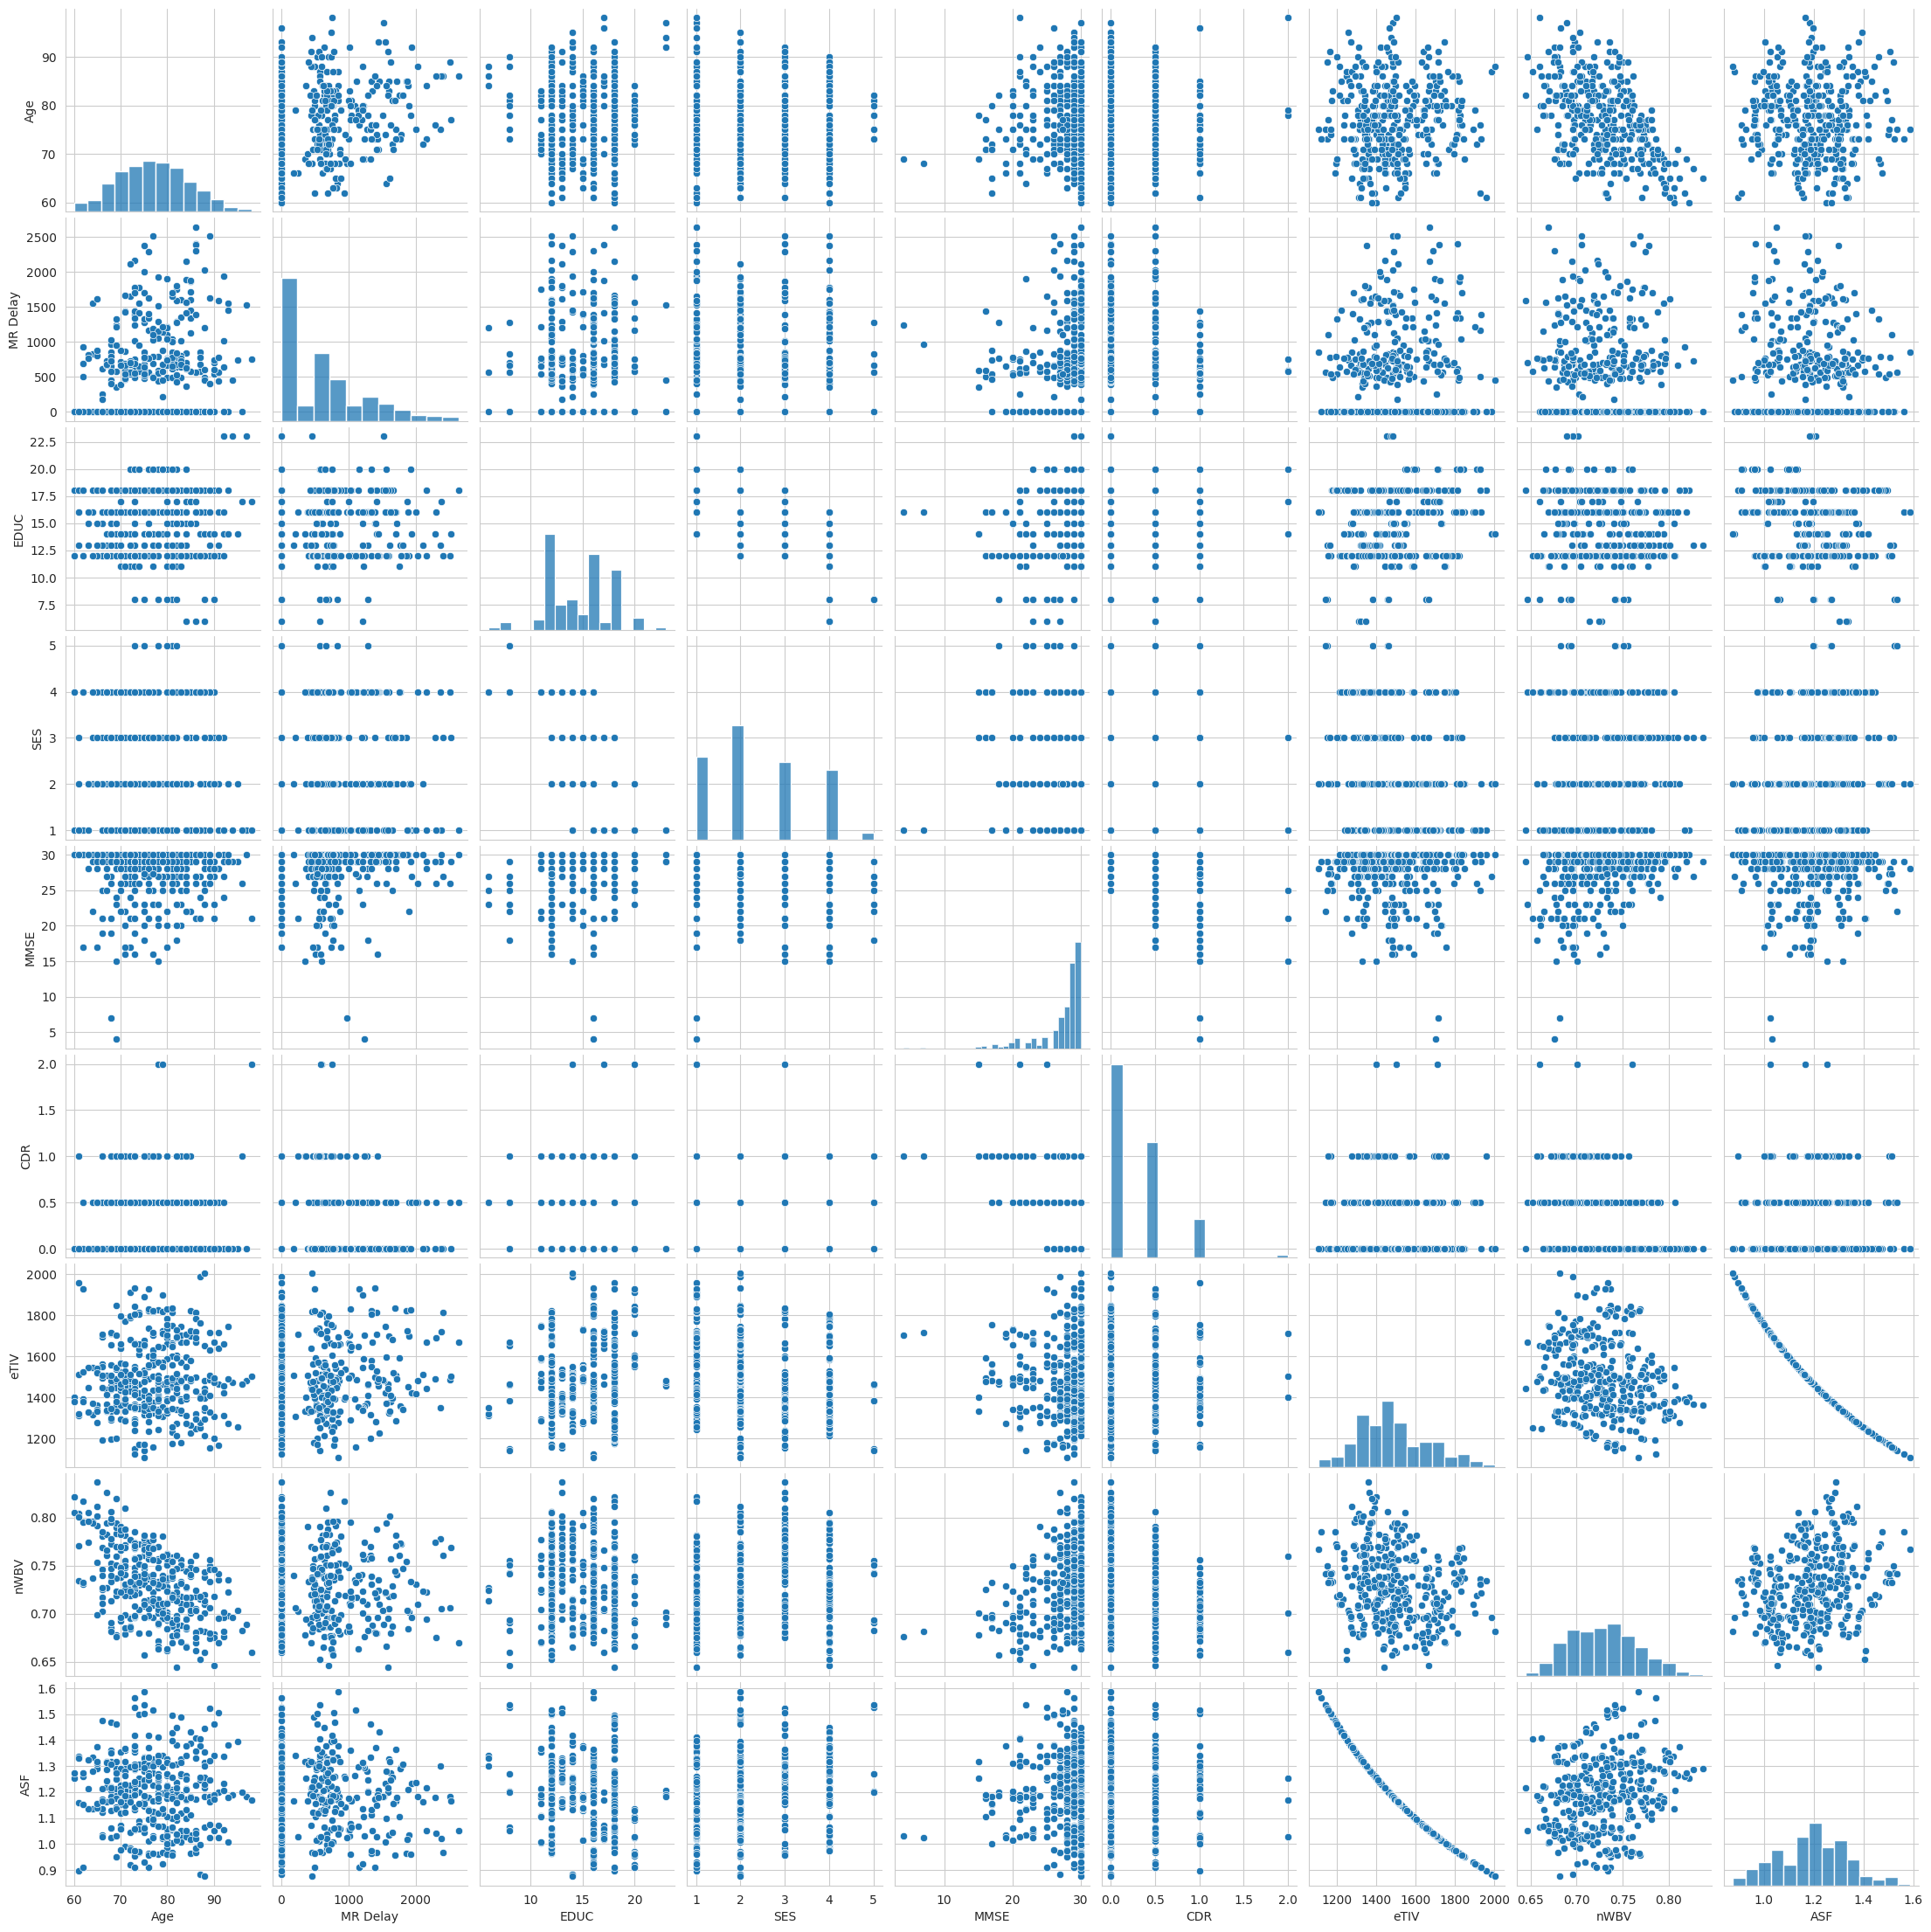

In [ ]:
from pylab import rcParams
rcParams['figure.figsize'] = 8,5
cols = ['Age','MR Delay', 'EDUC', 'SES', 'MMSE', 'CDR','eTIV','nWBV','ASF']
x=df.fillna('')
sns_plot = sns.pairplot(x[cols])

<ipython-input-18-6c96e63d7870>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df['SES'], orient="v",width=0.4, palette="colorblind",ax = axes[0][0]);
<ipython-input-18-6c96e63d7870>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df['EDUC'], orient="v",width=0.4, palette="colorblind",ax = axes[0][1]);
<ipython-input-18-6c96e63d7870>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df['MMSE'], orient="v",width=0.4, palette="colorblind",ax = axes[0][2]);
<ipython-input-18-6c96e63d7870>:8: FutureWarning: 

Passing `palette` w

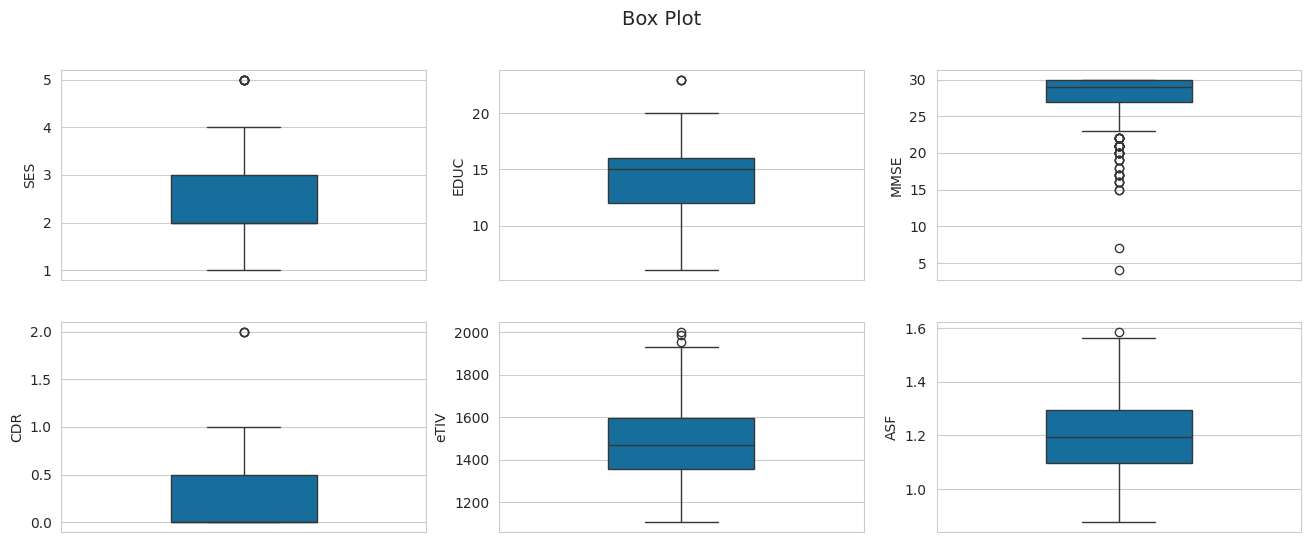

In [ ]:
#boxplots which shows the IQR(Interquartile Range )
fig, axes = plt.subplots(2,3,figsize = (16,6))
fig.suptitle("Box Plot",fontsize=14)
sns.set_style("whitegrid")
sns.boxplot(data=df['SES'], orient="v",width=0.4, palette="colorblind",ax = axes[0][0]);
sns.boxplot(data=df['EDUC'], orient="v",width=0.4, palette="colorblind",ax = axes[0][1]);
sns.boxplot(data=df['MMSE'], orient="v",width=0.4, palette="colorblind",ax = axes[0][2]);
sns.boxplot(data=df['CDR'], orient="v",width=0.4, palette="colorblind",ax = axes[1][0]);
sns.boxplot(data=df['eTIV'], orient="v",width=0.4, palette="colorblind",ax = axes[1][1]);
sns.boxplot(data=df['ASF'], orient="v",width=0.4, palette="colorblind",ax = axes[1][2]);
#xlabel("Time");

In [ ]:
#convet the charecter data into numeric
group_map = {"Demented": 1, "Nondemented": 0}

df['Group'] = df['Group'].map(group_map)
df['M/F'] = df['M/F'].replace(['F','M'], [0,1])

In [ ]:


def plot_correlation_map( df ):
    corr = df.corr()
    _ , ax = plt.subplots( figsize =( 12 , 10 ) )
    cmap = sns.diverging_palette( 240 , 10 , as_cmap = True )
    _ = sns.heatmap(corr,cmap = cmap,square=True, cbar_kws={ 'shrink' : .9 }, ax=ax, annot = True, annot_kws = { 'fontsize' : 12 })



In [ ]:
plot_correlation_map(df)

ValueError: could not convert string to float: 'OAS2_0001'

In [ ]:
# Encode columns into numeric
from sklearn.preprocessing import LabelEncoder
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])

In [ ]:
from sklearn.model_selection import train_test_split

feature_col_names = ["M/F", "Age", "EDUC", "SES", "MMSE","CDR", "eTIV", "nWBV", "ASF"]
predicted_class_names = ['Group']

X = df[feature_col_names].values
y = df[predicted_class_names].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [ ]:
from sklearn import metrics
def plot_confusion_metrix(y_test,model_test):
    cm = metrics.confusion_matrix(y_test, model_test)
    plt.figure(1)
    plt.clf()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Wistia)
    classNames = ['Nondemented','Demented']
    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames)
    plt.yticks(tick_marks, classNames)
    s = [['TN','FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            plt.text(j,i, str(s[i][j])+" = "+str(cm[i][j]))
    plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
def report_performance(model):

    model_test = model.predict(X_test)

    print("\n\nConfusion Matrix:")
    print("{0}".format(metrics.confusion_matrix(y_test, model_test)))
    print("\n\nClassification Report: ")
    print(metrics.classification_report(y_test, model_test))
    #cm = metrics.confusion_matrix(y_test, model_test)
    plot_confusion_metrix(y_test, model_test)

total_fpr = {}
total_tpr = {}
def roc_curves(model):
    predictions_test = model.predict(X_test)
    fpr, tpr, thresholds = roc_curve(predictions_test,y_test)
    roc_auc = auc(fpr, tpr)
    total_fpr[str((str(model).split('(')[0]))] = fpr
    total_tpr[str((str(model).split('(')[0]))] = tpr
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
total_accuracy = {}
def accuracy(model):
    pred = model.predict(X_test)
    accu = metrics.accuracy_score(y_test,pred)
    print("\nAcuuracy Of the Model: ",accu,"\n\n")
    total_accuracy[str((str(model).split('(')[0]))] = accu

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

#RandomForestClassifier

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(




Confusion Matrix:
[[36  2]
 [ 2 35]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        38
           1       0.95      0.95      0.95        37

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



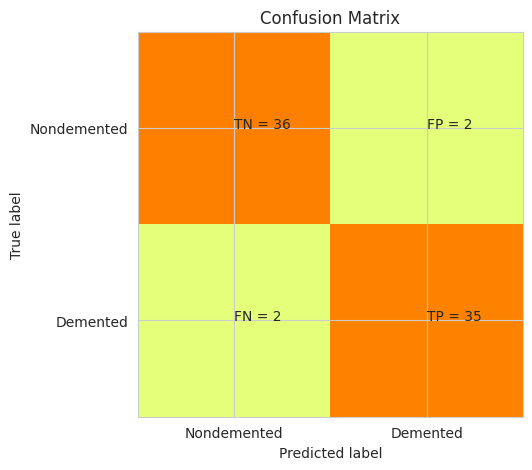

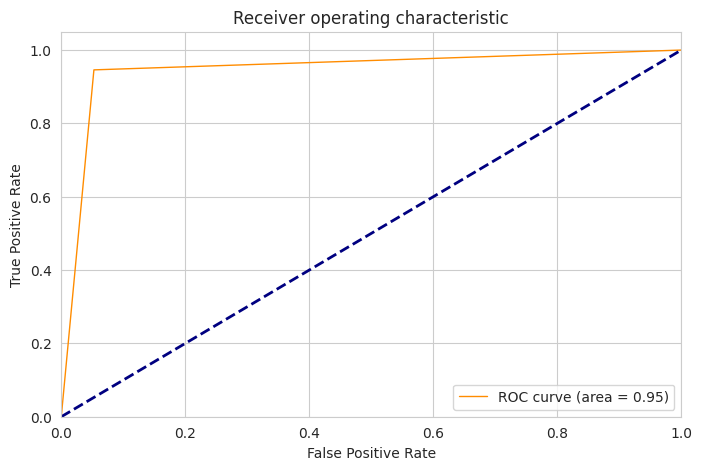


Acuuracy Of the Model:  0.9466666666666667 




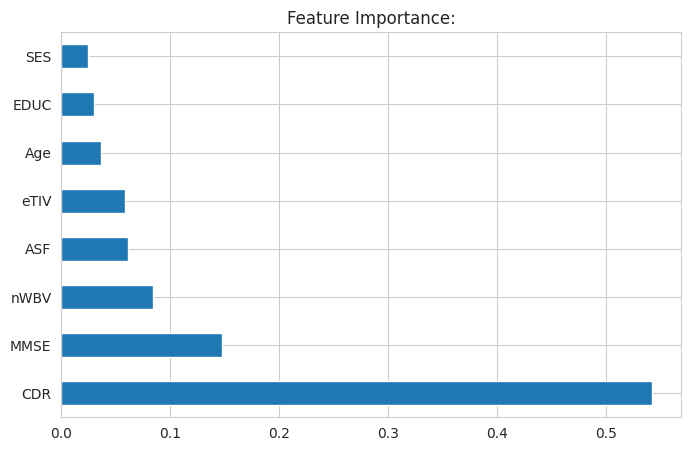

In [ ]:
rfc=RandomForestClassifier(criterion='gini',max_depth=8,max_features='auto',n_estimators=200)

param_grid = {
    'n_estimators': [200],
    'max_features': ['auto'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini']
}

#CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5,scoring = 'roc_auc')
rfc.fit(X_train, y_train.ravel())
#print("Best parameters set found on development set:")
#print(rfc.best_params_)
report_performance(rfc)
roc_curves(rfc)
accuracy(rfc)

feat_importances = pd.Series(rfc.feature_importances_, index=feature_col_names)
feat_importances.nlargest(8).plot(kind='barh')
plt.title("Feature Importance:")
plt.show()

#DecisionTreeClassifier



Confusion Matrix:
[[36  2]
 [ 2 35]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        38
           1       0.95      0.95      0.95        37

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



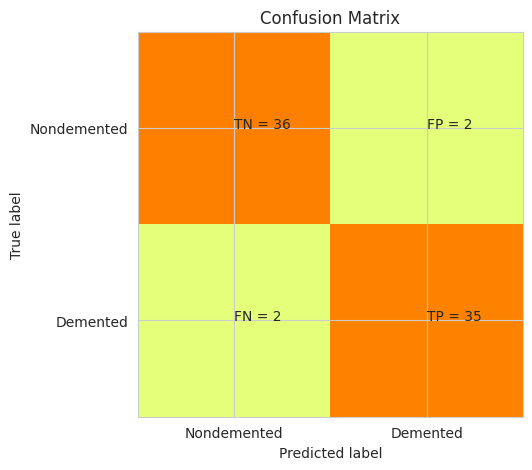

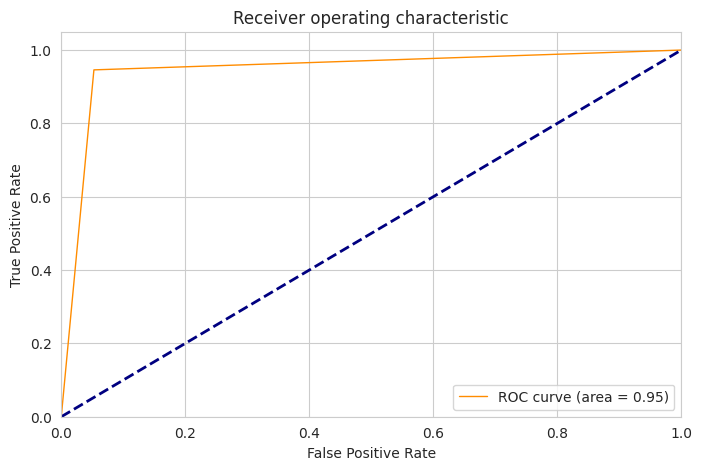


Acuuracy Of the Model:  0.9466666666666667 




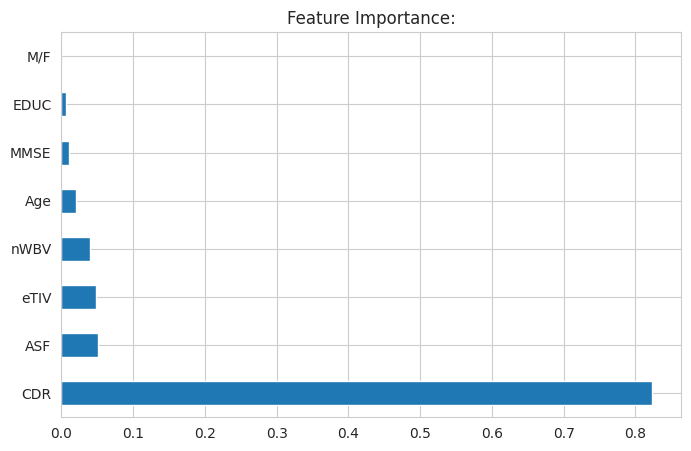

In [ ]:
clf_dtc = DecisionTreeClassifier(criterion='entropy',max_depth=5,random_state=0)
clf_dtc.fit(X_train, y_train.ravel())
report_performance(clf_dtc)
roc_curves(clf_dtc)
accuracy(clf_dtc)
#importances = clf.feature_importances_


feat_importances = pd.Series(clf_dtc.feature_importances_, index=feature_col_names)
feat_importances.nlargest(8).plot(kind='barh')
plt.title("Feature Importance:")
plt.show()

#XGBOOST



Confusion Matrix:
[[36  2]
 [ 2 35]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        38
           1       0.95      0.95      0.95        37

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



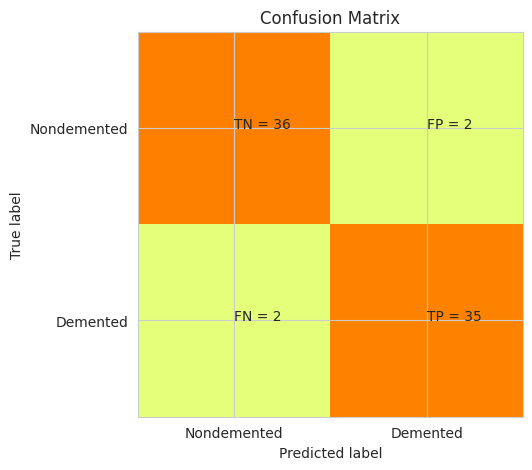

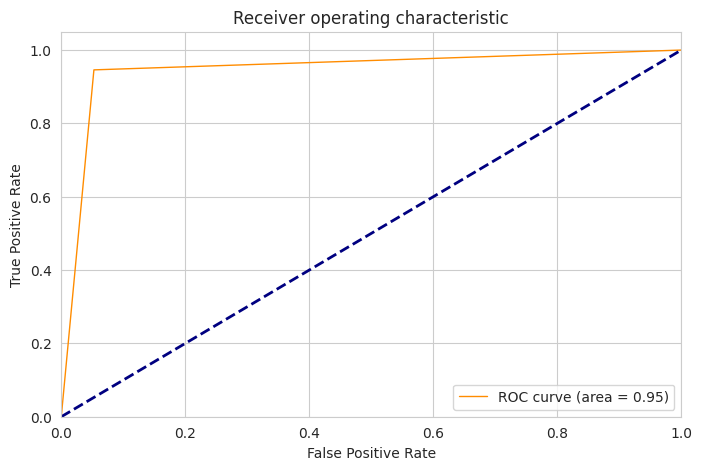


Acuuracy Of the Model:  0.9466666666666667 




In [ ]:
params = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [1,2,3,4,5]
        }

clf_xgb = XGBClassifier(random_state=0)
clf_xgb.fit(X_train, y_train.ravel())
report_performance(clf_xgb)
roc_curves(clf_xgb)
accuracy(clf_xgb)

#Voting Classifier

In [ ]:
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import feature_selection
from sklearn import model_selection

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 117, number of negative: 121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 238, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491597 -> initscore=-0.033617
[LightGBM] [Info] Start training from score -0.033617
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 117, number of negative: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 238, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491597 -> initscore=-0.033617
[LightGBM] [Info] Start training from score -0.033617
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


...

[LightGBM] [Info] Number of positive: 117, number of negative: 122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 239, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489540 -> initscore=-0.041847
[LightGBM] [Info] Start training from score -0.041847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 117, number of negative: 122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 239, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489540 -> initscore=-0.041847
[LightGBM] [Info] Start training from score -0.041847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 146, number of negative: 152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 298, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489933 -> initscore=-0.040274
[LightGBM] [Info] Start training from score -0.040274
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

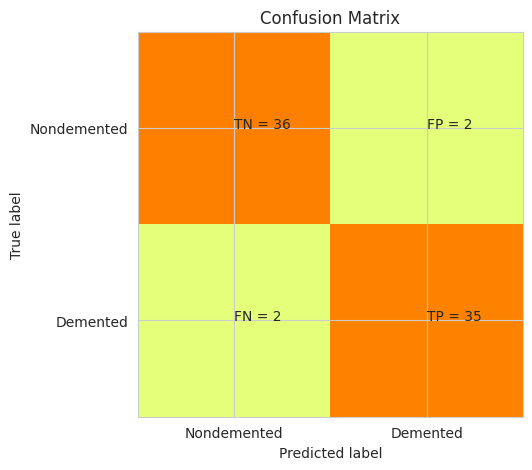

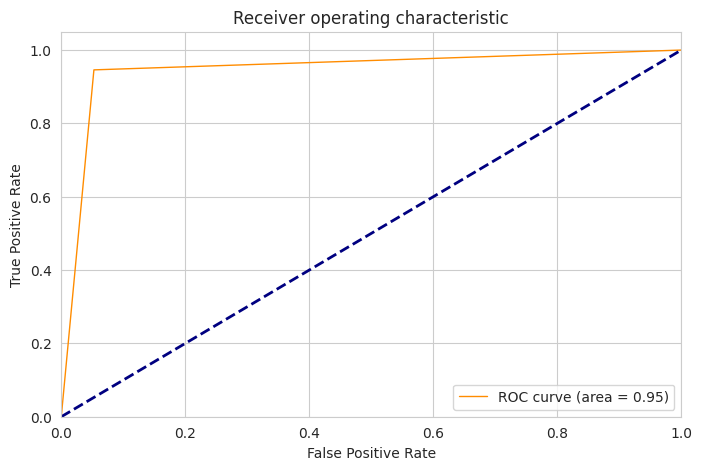


Acuuracy Of the Model:  0.9466666666666667 




/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 117, number of negative: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 238, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491597 -> initscore=-0.033617
[LightGBM] [Info] Start training from score -0.033617
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 117, number of negative: 121
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000057 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 238, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491597 -> initscore=-0.033617
[LightGBM] [Info] Start training from score -0.033617
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

...

[LightGBM] [Info] Number of positive: 117, number of negative: 122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 239, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489540 -> initscore=-0.041847
[LightGBM] [Info] Start training from score -0.041847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 117, number of negative: 122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 239, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489540 -> initscore=-0.041847
[LightGBM] [Info] Start training from score -0.041847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


[LightGBM] [Info] Number of positive: 146, number of negative: 152
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 298, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489933 -> initscore=-0.040274
[LightGBM] [Info] Start training from score -0.040274
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

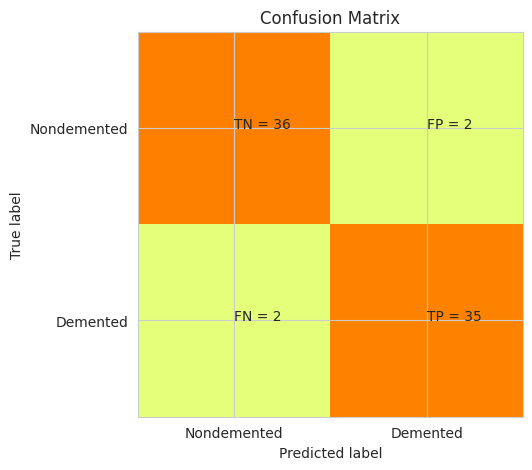

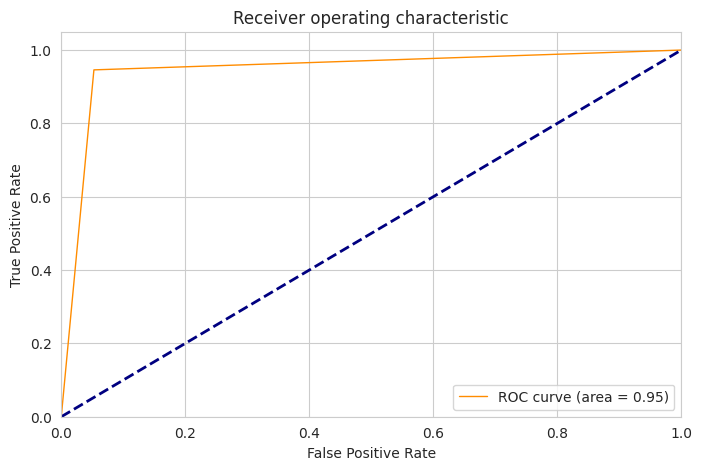


Acuuracy Of the Model:  0.9466666666666667 




In [ ]:
vote_est = [('etc',ensemble.ExtraTreesClassifier()),
            ('gb',GradientBoostingClassifier()),
            ('abc',AdaBoostClassifier()),
    ('rfc', ensemble.RandomForestClassifier(criterion='gini', max_depth=8, max_features='auto', n_estimators=200)),
    #('svc', svm.SVC(probability=True)),
    #('xgb', XGBClassifier()),
            ('lbgm',LGBMClassifier())
           ]


vote_hard = ensemble.VotingClassifier(estimators = vote_est , voting = 'hard')
vote_hard_cv = model_selection.cross_validate(vote_hard, X_train, y_train.ravel())
vote_hard.fit(X_train, y_train.ravel())
report_performance(vote_hard)
roc_curves(vote_hard)
accuracy(vote_hard)
#pred = vote_hard.predict(X_test)
#accu = metrics.accuracy_score(y_test,pred)
#print("\nAcuuracy Of the Model: ",accu,"\n\n")

vote_soft = ensemble.VotingClassifier(estimators = vote_est , voting = 'soft')
vote_soft_cv = model_selection.cross_validate(vote_soft, X_train, y_train.ravel())
vote_soft.fit(X_train, y_train.ravel())
report_performance(vote_soft)
roc_curves(vote_soft)
accuracy(vote_soft)
#pred = vote_soft.predict(X_test)
#accu = metrics.accuracy_score(y_test,pred)
#print("\nAcuuracy Of the Model: ",accu,"\n\n")

#Other Classifiers

In [ ]:
clfs =[ExtraTreesClassifier(),GradientBoostingClassifier(),AdaBoostClassifier()]

ExtraTreesClassifier : 


Confusion Matrix:
[[35  3]
 [ 2 35]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.92      0.93        38
           1       0.92      0.95      0.93        37

    accuracy                           0.93        75
   macro avg       0.93      0.93      0.93        75
weighted avg       0.93      0.93      0.93        75



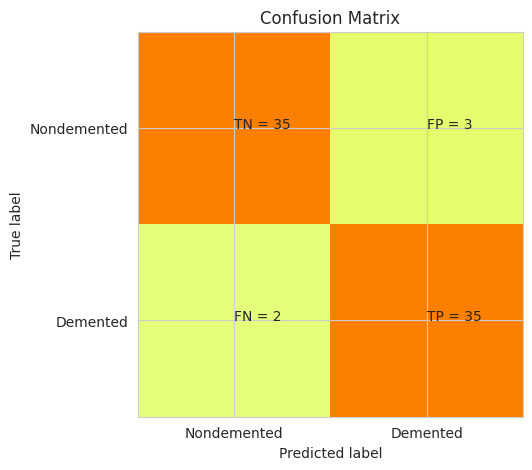

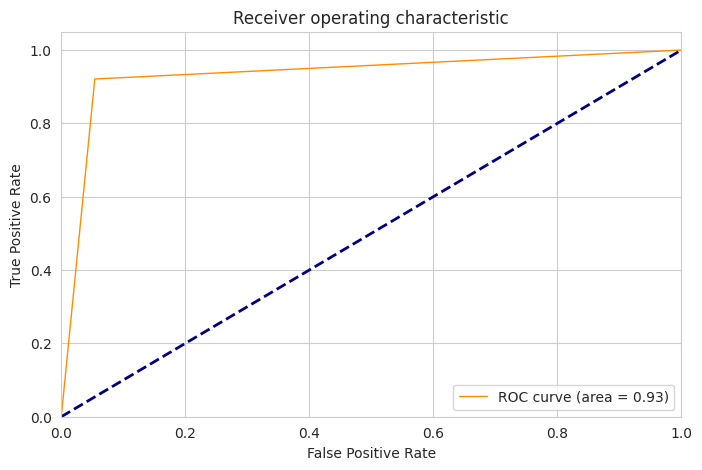


Acuuracy Of the Model:  0.9333333333333333 


GradientBoostingClassifier : 


Confusion Matrix:
[[35  3]
 [ 2 35]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.92      0.93        38
           1       0.92      0.95      0.93        37

    accuracy                           0.93        75
   macro avg       0.93      0.93      0.93        75
weighted avg       0.93      0.93      0.93        75



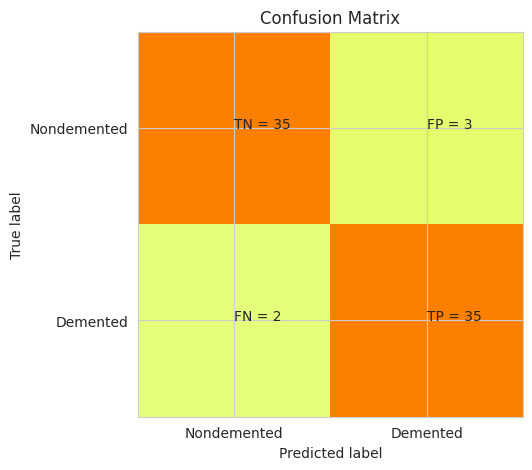

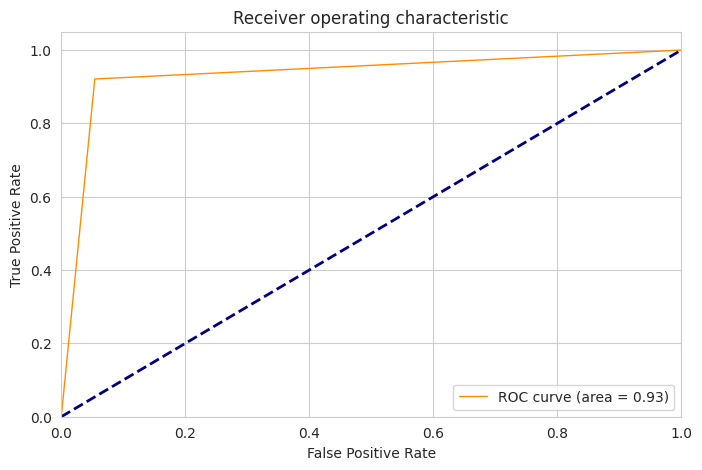


Acuuracy Of the Model:  0.9333333333333333 


AdaBoostClassifier : 


Confusion Matrix:
[[34  4]
 [ 4 33]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        38
           1       0.89      0.89      0.89        37

    accuracy                           0.89        75
   macro avg       0.89      0.89      0.89        75
weighted avg       0.89      0.89      0.89        75



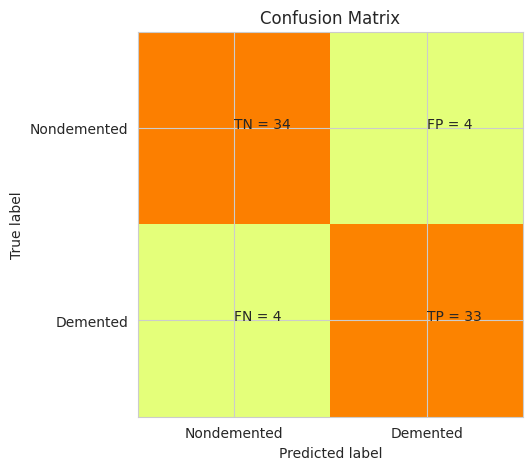

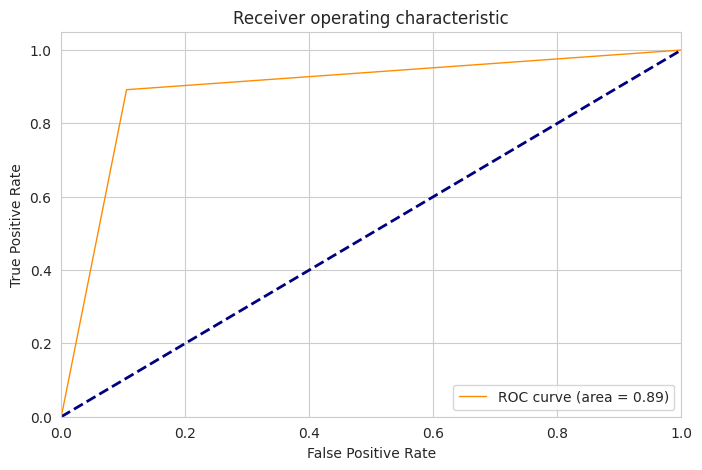


Acuuracy Of the Model:  0.8933333333333333 




In [ ]:
for model in clfs:
    print(str(model).split('(')[0],": ")
    model.fit(X_train,y_train.ravel())
    X = pd.DataFrame(X_train)
    report_performance(model)
    roc_curves(model)
    accuracy(model)

#Model Comparison

In [ ]:
data = total_accuracy.values()
labels = total_accuracy.keys()

Text(0, 0.5, 'Accuracy')

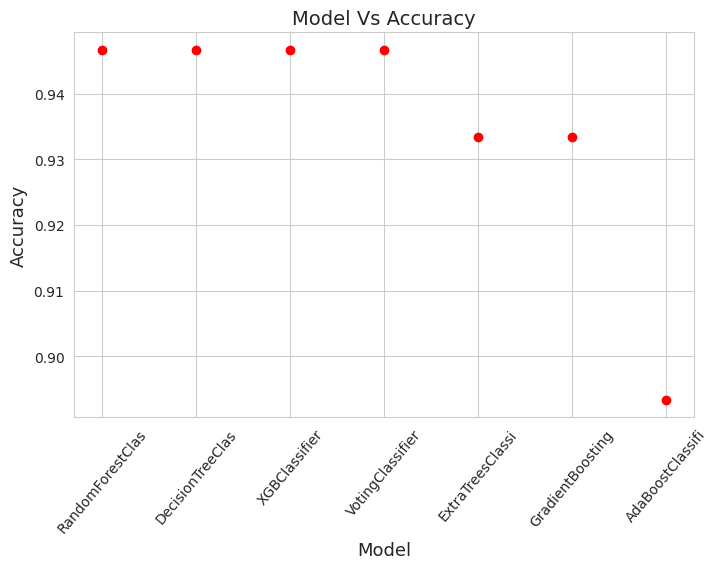

In [ ]:
plt.plot([i for i, e in enumerate(data)], data, 'ro'); plt.xticks([i for i, e in enumerate(labels)], [l[0:16] for l in labels])
plt.title("Model Vs Accuracy",fontsize = 14)
plt.xlabel('Model',fontsize = 13)
plt.xticks(rotation = 50)
plt.ylabel('Accuracy',fontsize = 13)

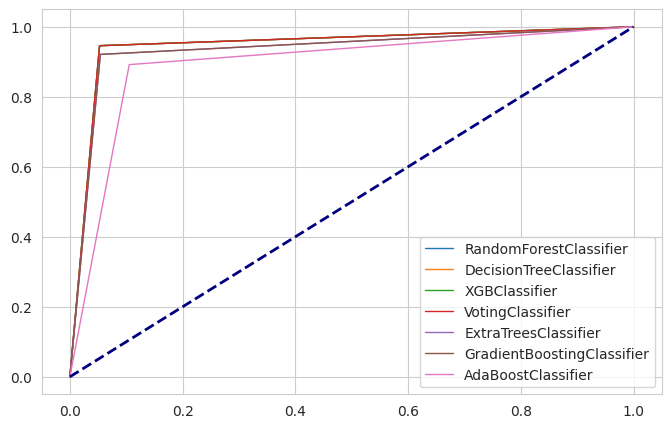

In [ ]:


for i in total_fpr.keys():
    plt.plot(total_fpr[i],total_tpr[i],lw=1, label=i)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.legend()



In [ ]:
!pip install numpy tensorflow scikit-learn


#LSTM

Epoch 1/200
8/8 [==============================] - 6s 53ms/step - loss: 0.6842 - accuracy: 0.5504 - val_loss: 0.6636 - val_accuracy: 0.7167
Epoch 2/200
8/8 [==============================] - 0s 10ms/step - loss: 0.6613 - accuracy: 0.7437 - val_loss: 0.6316 - val_accuracy: 0.8667
Epoch 3/200
8/8 [==============================] - 0s 11ms/step - loss: 0.6318 - accuracy: 0.8277 - val_loss: 0.5909 - val_accuracy: 0.9167
Epoch 4/200
8/8 [==============================] - 0s 12ms/step - loss: 0.5915 - accuracy: 0.8571 - val_loss: 0.5356 - val_accuracy: 0.9167
Epoch 5/200
8/8 [==============================] - 0s 11ms/step - loss: 0.5449 - accuracy: 0.8613 - val_loss: 0.4679 - val_accuracy: 0.9333
Epoch 6/200
8/8 [==============================] - 0s 9ms/step - loss: 0.4856 - accuracy: 0.8908 - val_loss: 0.3962 - val_accuracy: 0.9500
Epoch 7/200
8/8 [==============================] - 0s 10ms/step - loss: 0.4286 - accuracy: 0.8908 - val_loss: 0.3280 - val_accuracy: 0.9500
Epoch 8/200
8/8 [====

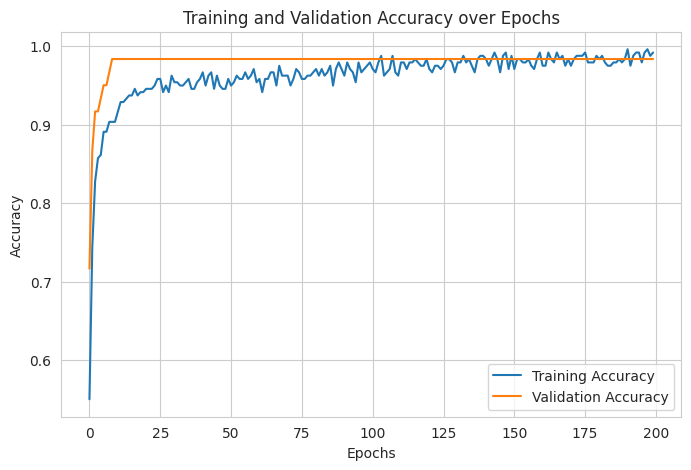

3/3 [==============================] - 0s 9ms/step - loss: 0.3193 - accuracy: 0.9467
LSTM Accuracy: 0.9466666579246521


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for LSTM (assuming time steps = 1)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(64, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # Adjust learning rate
lstm_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
epochs = 200
history = lstm_model.fit(X_train_lstm, y_train, epochs=epochs, batch_size=32, validation_split=0.2)

# Plotting accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the LSTM model
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test)
print(f"LSTM Accuracy: {lstm_accuracy}")


#BLSTM

Epoch 1/200
8/8 [==============================] - 9s 207ms/step - loss: 0.7179 - accuracy: 0.5840 - val_loss: 0.6894 - val_accuracy: 0.5167 - lr: 0.0010
Epoch 2/200
8/8 [==============================] - 0s 65ms/step - loss: 0.4781 - accuracy: 0.7479 - val_loss: 0.6859 - val_accuracy: 0.5167 - lr: 0.0010
Epoch 3/200
8/8 [==============================] - 0s 36ms/step - loss: 0.4061 - accuracy: 0.8109 - val_loss: 0.6824 - val_accuracy: 0.5167 - lr: 0.0010
Epoch 4/200
8/8 [==============================] - 0s 41ms/step - loss: 0.3305 - accuracy: 0.8697 - val_loss: 0.6795 - val_accuracy: 0.5167 - lr: 0.0010
Epoch 5/200
8/8 [==============================] - 0s 39ms/step - loss: 0.3298 - accuracy: 0.8866 - val_loss: 0.6753 - val_accuracy: 0.5333 - lr: 0.0010
Epoch 6/200
8/8 [==============================] - 0s 42ms/step - loss: 0.2935 - accuracy: 0.8824 - val_loss: 0.6712 - val_accuracy: 0.5333 - lr: 0.0010
Epoch 7/200
8/8 [==============================] - 0s 44ms/step - loss: 0.2992 - 

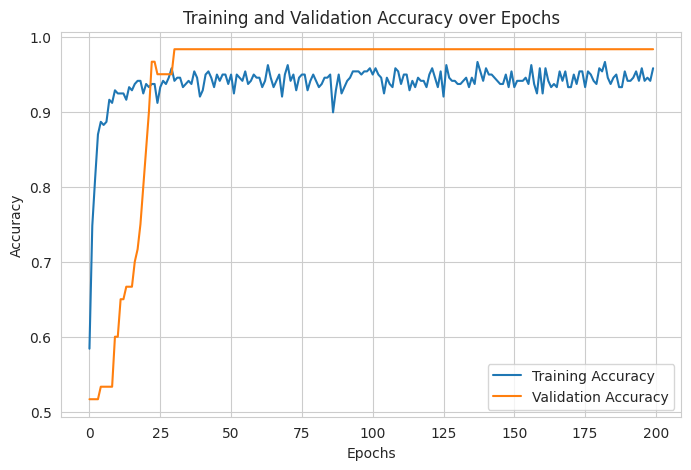

3/3 [==============================] - 0s 7ms/step - loss: 0.1600 - accuracy: 0.9600
BLSTM Accuracy: 0.9599999785423279


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import LearningRateScheduler

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape the input data for BLSTM (assuming time steps = 1)
X_train_blstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_blstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# BLSTM model
blstm_model = Sequential()
blstm_model.add(Bidirectional(LSTM(128, activation='relu', return_sequences=True), input_shape=(X_train_blstm.shape[1], X_train_blstm.shape[2])))
blstm_model.add(Dropout(0.5))
blstm_model.add(BatchNormalization())
blstm_model.add(Bidirectional(LSTM(64, activation='relu')))
blstm_model.add(Dropout(0.5))
blstm_model.add(BatchNormalization())
blstm_model.add(Dense(32, activation='relu'))
blstm_model.add(Dense(1, activation='sigmoid'))

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # Adjust learning rate
blstm_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Learning rate scheduling callback
def scheduler(epoch, lr):
    if epoch < 30:
        return lr
    else:
        return lr * tf.math.exp(-0.2)

lr_scheduler = LearningRateScheduler(scheduler)

# Train the model
epochs = 200
history = blstm_model.fit(X_train_blstm, y_train, epochs=epochs, batch_size=32, validation_split=0.2, callbacks=[lr_scheduler])

# Plotting accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the BLSTM model
blstm_loss, blstm_accuracy = blstm_model.evaluate(X_test_blstm, y_test)
print(f"BLSTM Accuracy: {blstm_accuracy}")


3/3 [==============================] - 0s 6ms/step - loss: 0.1600 - accuracy: 0.9600


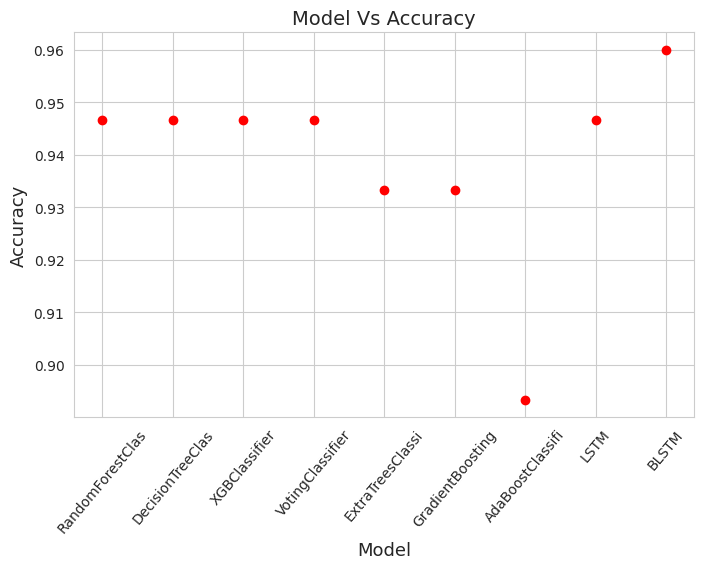

In [ ]:
lstm_model_accuracy = lstm_model.evaluate(X_test_lstm, y_test)[1]
total_accuracy['LSTM'] = lstm_model_accuracy

# BLSTM model
blstm_model_accuracy = blstm_model.evaluate(X_test_blstm, y_test)[1]
total_accuracy['BLSTM'] = blstm_model_accuracy

# Plotting accuracy
data = total_accuracy.values()
labels = total_accuracy.keys()
plt.plot([i for i, e in enumerate(data)], data, 'ro'); plt.xticks([i for i, e in enumerate(labels)], [l[0:16] for l in labels])
plt.title("Model Vs Accuracy", fontsize=14)
plt.xlabel('Model', fontsize=13)
plt.xticks(rotation=50)
plt.ylabel('Accuracy', fontsize=13)
plt.show()

# Stacking Classifier

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score

# Base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(kernel='linear', C=1)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('ada', AdaBoostClassifier(n_estimators=50, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('bag', BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)),
    # Add more base models as needed
]

# Meta-model
meta_model = LogisticRegression()

# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Cross-validate the stacking model
stacking_scores = cross_val_score(stacking_model, X_train, y_train.ravel(), cv=5, scoring='accuracy')
print("Stacking Model Accuracy: {:.2f}% (+/- {:.2f}%)".format(stacking_scores.mean() * 100, stacking_scores.std() * 2 * 100))


Stacking Model Accuracy: 93.64% (+/- 9.75%)


In [ ]:
# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Cross-validate the stacking model
stacking_scores = cross_val_score(stacking_model, X_train, y_train.ravel(), cv=5, scoring='accuracy')
stacking_model_accuracy = stacking_scores.mean()

# Add stacking model accuracy to the total_accuracy dictionary
total_accuracy['Stacking'] = stacking_model_accuracy

# Plotting accuracy
data = total_accuracy.values()
labels = total_accuracy.keys()
plt.plot([i for i, e in enumerate(data)], data, 'ro')
plt.xticks([i for i, e in enumerate(labels)], [l[0:16] for l in labels])
plt.title("Model Vs Accuracy", fontsize=14)
plt.xlabel('Model', fontsize=13)
plt.xticks(rotation=50)
plt.ylabel('Accuracy', fontsize=13)
plt.show()


#SVC



Confusion Matrix:
[[37  1]
 [ 2 35]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        38
           1       0.97      0.95      0.96        37

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



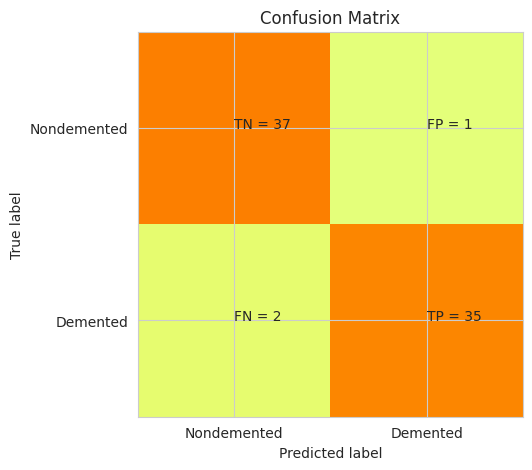

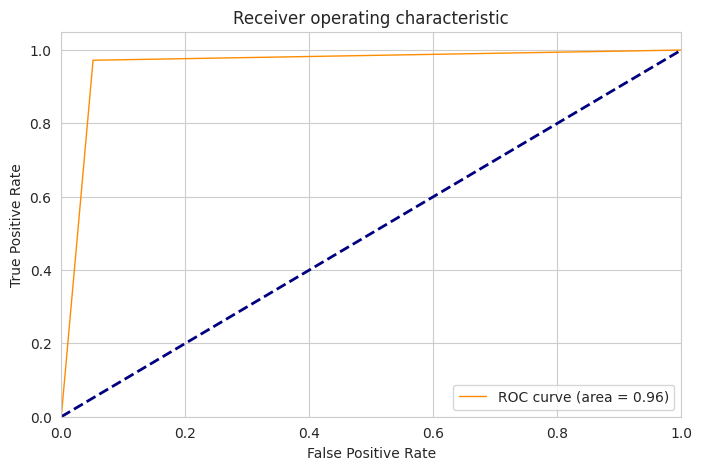


Acuuracy Of the Model:  0.96 




In [ ]:
svm = SVC(kernel="linear", C=0.1,random_state=0)
svm.fit(X_train, y_train.ravel())
report_performance(svm)
roc_curves(svm)
accuracy(svm)

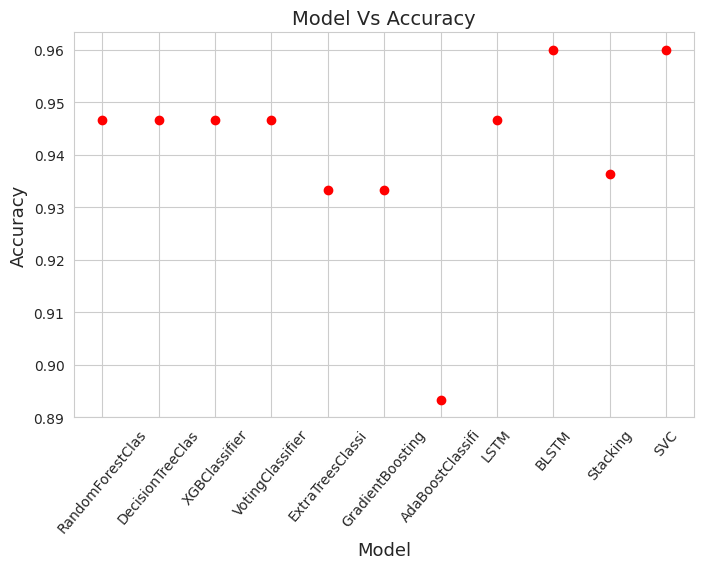

In [ ]:
# Plotting accuracy
data = total_accuracy.values()
labels = total_accuracy.keys()
plt.plot([i for i, e in enumerate(data)], data, 'ro')
plt.xticks([i for i, e in enumerate(labels)], [l[0:16] for l in labels])
plt.title("Model Vs Accuracy", fontsize=14)
plt.xlabel('Model', fontsize=13)
plt.xticks(rotation=50)
plt.ylabel('Accuracy', fontsize=13)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Your data
data = total_accuracy.values()
labels = total_accuracy.keys()

# Create a plot with a darker background
plt.figure(facecolor='firebrick')

# Plotting
plt.plot([i for i, e in enumerate(data)], data, 'ro', color='darkred')  # Set plot color to dark red
plt.xticks([i for i, e in enumerate(labels)], [l[0:16] for l in labels], color='lightgray')  # Set x-ticks and labels color to light gray
plt.title("Model Vs Accuracy", fontsize=14, color='white')  # Set title color to white
plt.xlabel('Model', fontsize=13, color='white')  # Set x-label color to light gray
plt.xticks(rotation=50, color='lightgray')  # Rotate x-ticks and set color to light gray for better visibility

plt.ylabel('Accuracy', fontsize=13, color='white')  # Set y-label color to light gray

# Set the color of the axis labels and ticks
plt.gca().spines['bottom'].set_color('white')  # Set x-axis color to dim gray
plt.gca().spines['left'].set_color('white')  # Set y-axis color to dim gray
plt.tick_params(axis='x', colors='white')  # Set x-ticks color to dim gray
plt.tick_params(axis='y', colors='white')  # Set y-ticks color to dim gray

# Set the color of the grid lines
plt.grid(color='dimgray')  # Set grid color to dim gray

plt.show()


In [ ]:
!pip install tabulate



In [ ]:
# Create a dictionary to store model names and accuracy values
accuracy_dict = {model_name: accuracy_value for model_name, accuracy_value in total_accuracy.items()}

# Sort the dictionary by accuracy values in decreasing order
sorted_accuracy_dict = dict(sorted(accuracy_dict.items(), key=lambda item: item[1], reverse=True))




In [ ]:
from tabulate import tabulate

# Create a list to store model names and accuracy values as tuples
table_data = [(model_name, f"{accuracy_value * 100:.4f}%") for model_name, accuracy_value in sorted_accuracy_dict.items()]

# Print the sorted results in a table format
table_headers = ["Model", "Accuracy"]
print(tabulate(table_data, headers=table_headers, tablefmt="pretty"))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
import joblib



# Define the path to save the model in your Drive
model_path = '/content/drive/My Drive/svm2_model.pkl'

# Save the model to your Drive
joblib.dump(svm, model_path)


In [ ]:
from sklearn.svm import SVC
import numpy as np


user_input = []
for feature_name in feature_col_names:
    value = float(input(f"Enter value for {feature_name}: "))
    user_input.append(value)

# Convert the user input to a numpy array
user_input_array = np.array(user_input).reshape(1, -1)

# Use the trained SVM model to predict the output for the unseen example
prediction = svm.predict(user_input_array)

# Print the prediction
if prediction[0] == 1:
    print("The model predicts: Demented")
else:
    print("The model predicts: Nondemented")



['svm_model.pkl']